In [1]:
import boto3
import pandas as pd
import io

s3 = boto3.client("s3")

bucket = "traffic-analysis-personal"

def read_csv_from_s3(bucket_name, key):
    obj = s3.get_object(Bucket=bucket_name, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

In [3]:
hourly = read_csv_from_s3(
    bucket,
    "analytics/hourly_trips.csv"
)

zones = read_csv_from_s3(
    bucket,
    "analytics/top_pickup_zones.csv"
)

duration = read_csv_from_s3(
    bucket,
    "analytics/avg_duration_by_hour.csv"
)

hotspots = read_csv_from_s3(
    bucket,
    "analytics/congestion_hotspots.csv"
)

metrics = read_csv_from_s3(
    bucket,
    "ml/ml_metrics/part-00001-bdda40b4-0239-427d-a9ad-97b9b557c09a-c000.csv"
)

In [4]:
hourly.head()
zones.head()
duration.head()
hotspots.head()
metrics.head()

,model,rmse,mae,r2
0,Random Forest,6.038596,4.113199,0.697494


In [5]:
import matplotlib.pyplot as plt
import numpy as np

## Graph 1: Trips by Hour

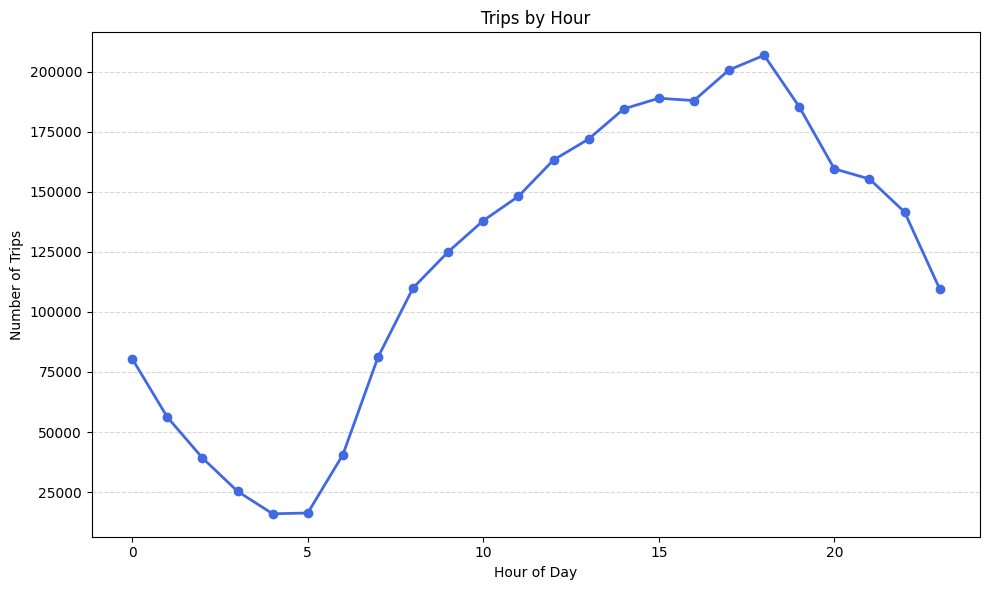

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(
    hourly["pickup_hour"],
    hourly["count"],
    marker="o",
    linewidth=2,
    color="royalblue"
)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Trips by Hour")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Graph 2: Top Pickup Zones

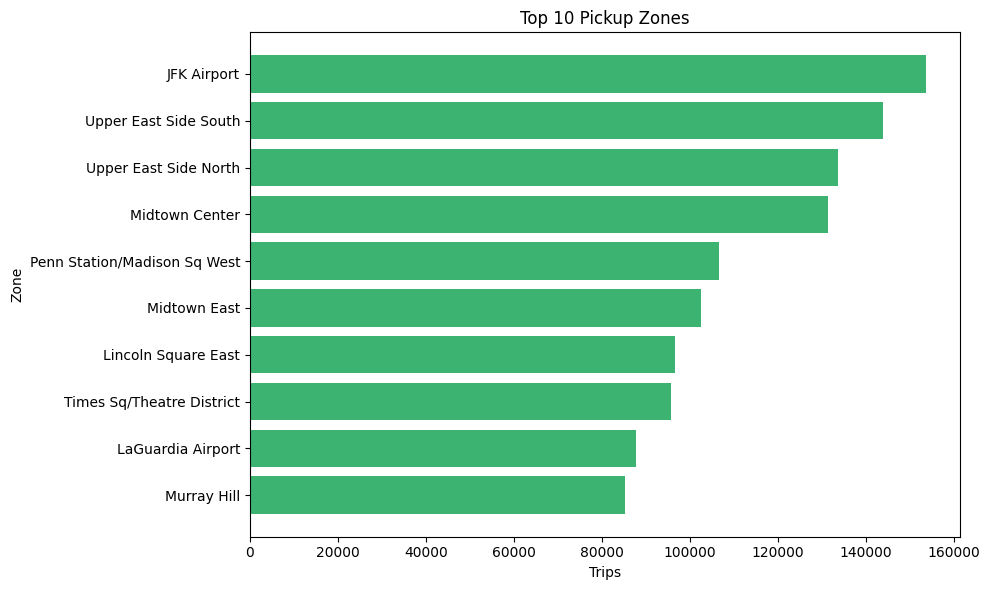

In [7]:
top_zones = zones.head(10).sort_values(by="count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_zones["PU_Zone"],
    top_zones["count"],
    color="mediumseagreen"
)
plt.xlabel("Trips")
plt.ylabel("Zone")
plt.title("Top 10 Pickup Zones")
plt.tight_layout()
plt.show()

## Graph 3: Average Duration by Hour

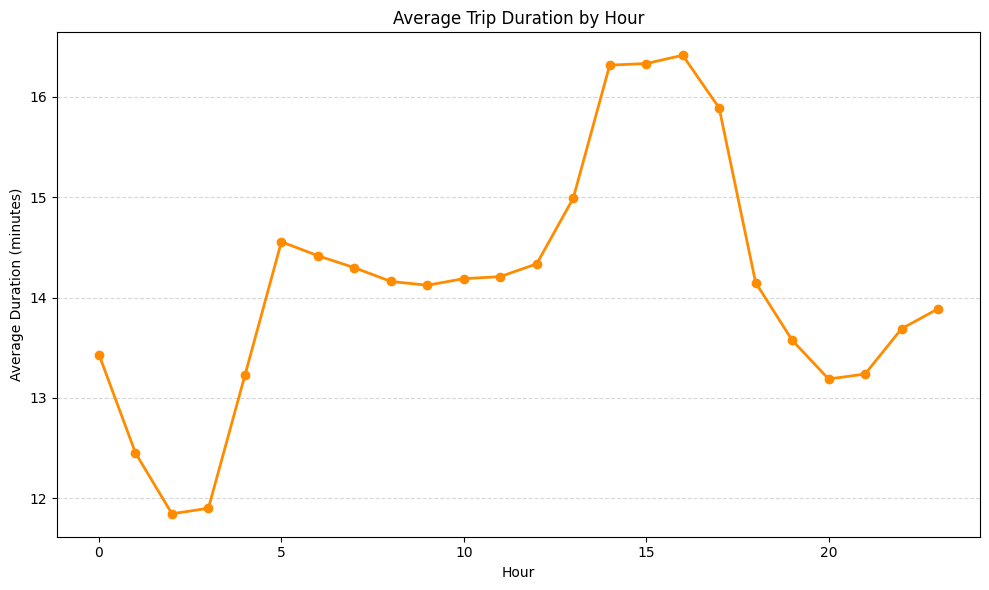

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(
    duration["pickup_hour"],
    duration["avg_trip_duration"],
    marker="o",
    linewidth=2,
    color="darkorange"
)
plt.xlabel("Hour")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Trip Duration by Hour")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Graph 4: Congestion Hotspots

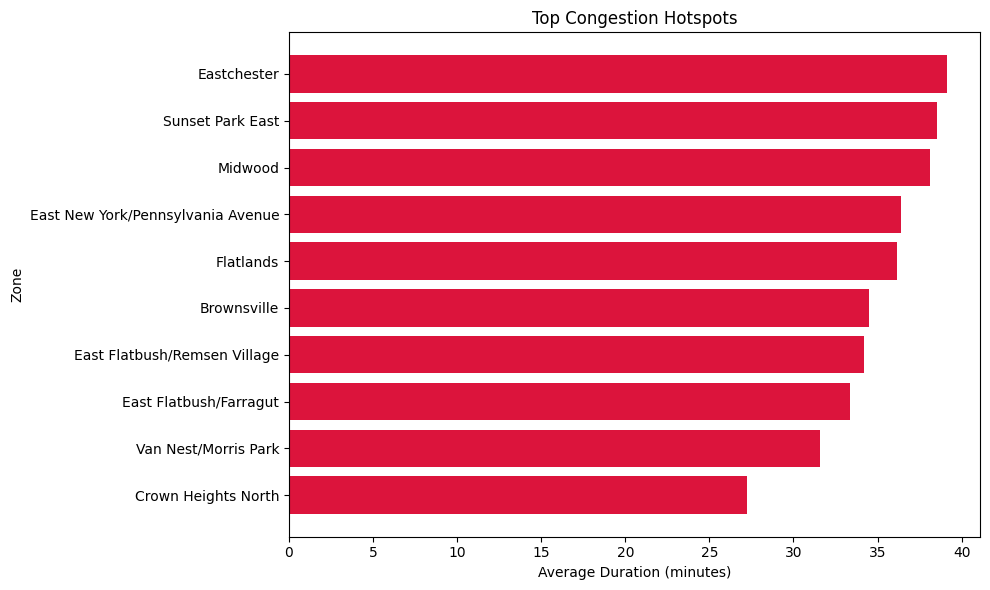

In [9]:
top_hotspots = hotspots.head(10).sort_values(by="avg_duration", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_hotspots["PU_Zone"],
    top_hotspots["avg_duration"],
    color="crimson"
)
plt.xlabel("Average Duration (minutes)")
plt.ylabel("Zone")
plt.title("Top Congestion Hotspots")
plt.tight_layout()
plt.show()

## Graph 5: Model Comparison

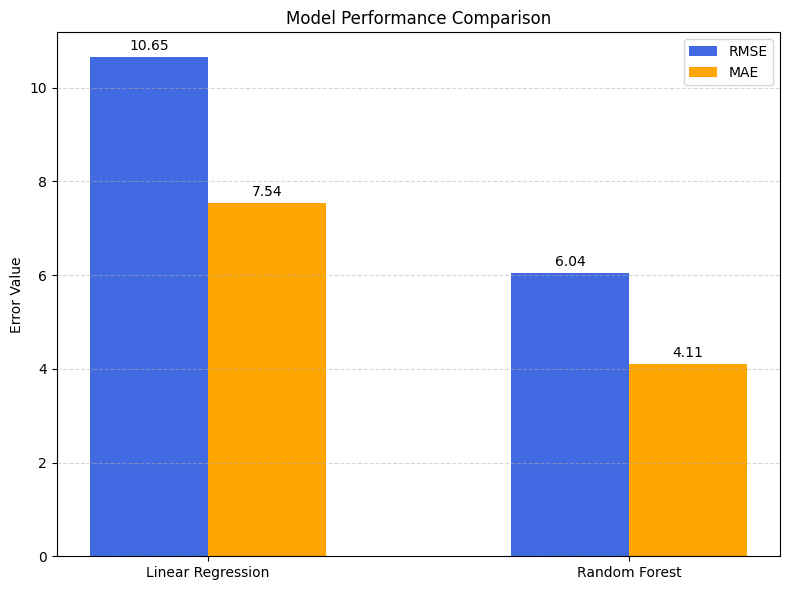

In [11]:
models = ["Linear Regression", "Random Forest"]
rmse = [10.65, 6.04]
mae = [7.54, 4.11]

x = np.arange(len(models))
bar_width = 0.28

plt.figure(figsize=(8, 6))
plt.bar(x - bar_width/2, rmse, width=bar_width, label="RMSE", color="royalblue")
plt.bar(x + bar_width/2, mae, width=bar_width, label="MAE", color="orange")

plt.xticks(x, models)
plt.ylabel("Error Value")
plt.title("Model Performance Comparison")

for i in range(len(models)):
    plt.text(x[i] - bar_width/2, rmse[i] + 0.15, f"{rmse[i]:.2f}", ha="center")
    plt.text(x[i] + bar_width/2, mae[i] + 0.15, f"{mae[i]:.2f}", ha="center")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

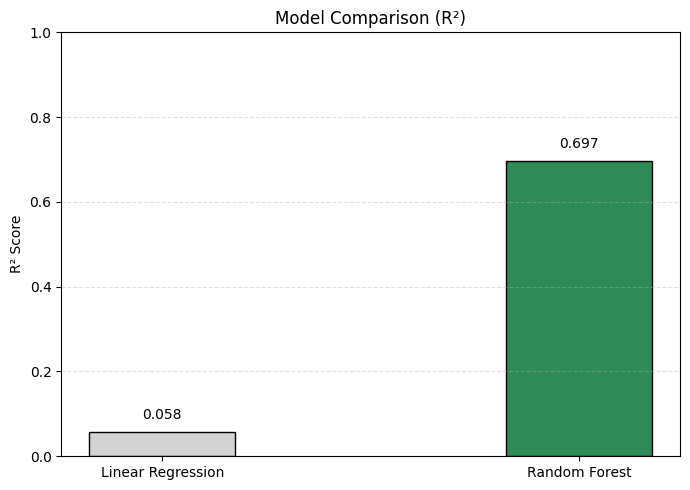

In [12]:
r2 = [0.058, 0.697]

plt.figure(figsize=(7, 5))
bars = plt.bar(
    x,
    r2,
    width=0.35,
    color=["lightgray", "seagreen"],
    edgecolor="black"
)

plt.xticks(x, models)
plt.ylabel("R² Score")
plt.title("Model Comparison (R²)")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.03,
        f"{yval:.3f}",
        ha="center"
    )

plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()